In [5]:
import numpy as np
import matplotlib.pyplot as plt

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITLE_FSIZE = 14
LABEL_FSIZE = 12
TICK_FSIZE = 10
REF_LINE_COLOR = 'gray'

plt.rc('text', usetex=True)
plt.rc('font', family='serif') 
plt.rc('grid', linestyle='--', alpha=0.3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.1

# Data

In [3]:
df_all = pd.read_csv("combined_dmrg_stats.csv")

# Fig.1(c) Manuscript

Selected EA L: [ 8. 10. 12. 14. 16. 18. 20. 22. 24. 26. 28. 30. 32.]
Selected FM L: [ 8. 12. 16. 20.]
Saved high-quality PDF as: Figs/AFM-Heisenberg-DMRG.pdf


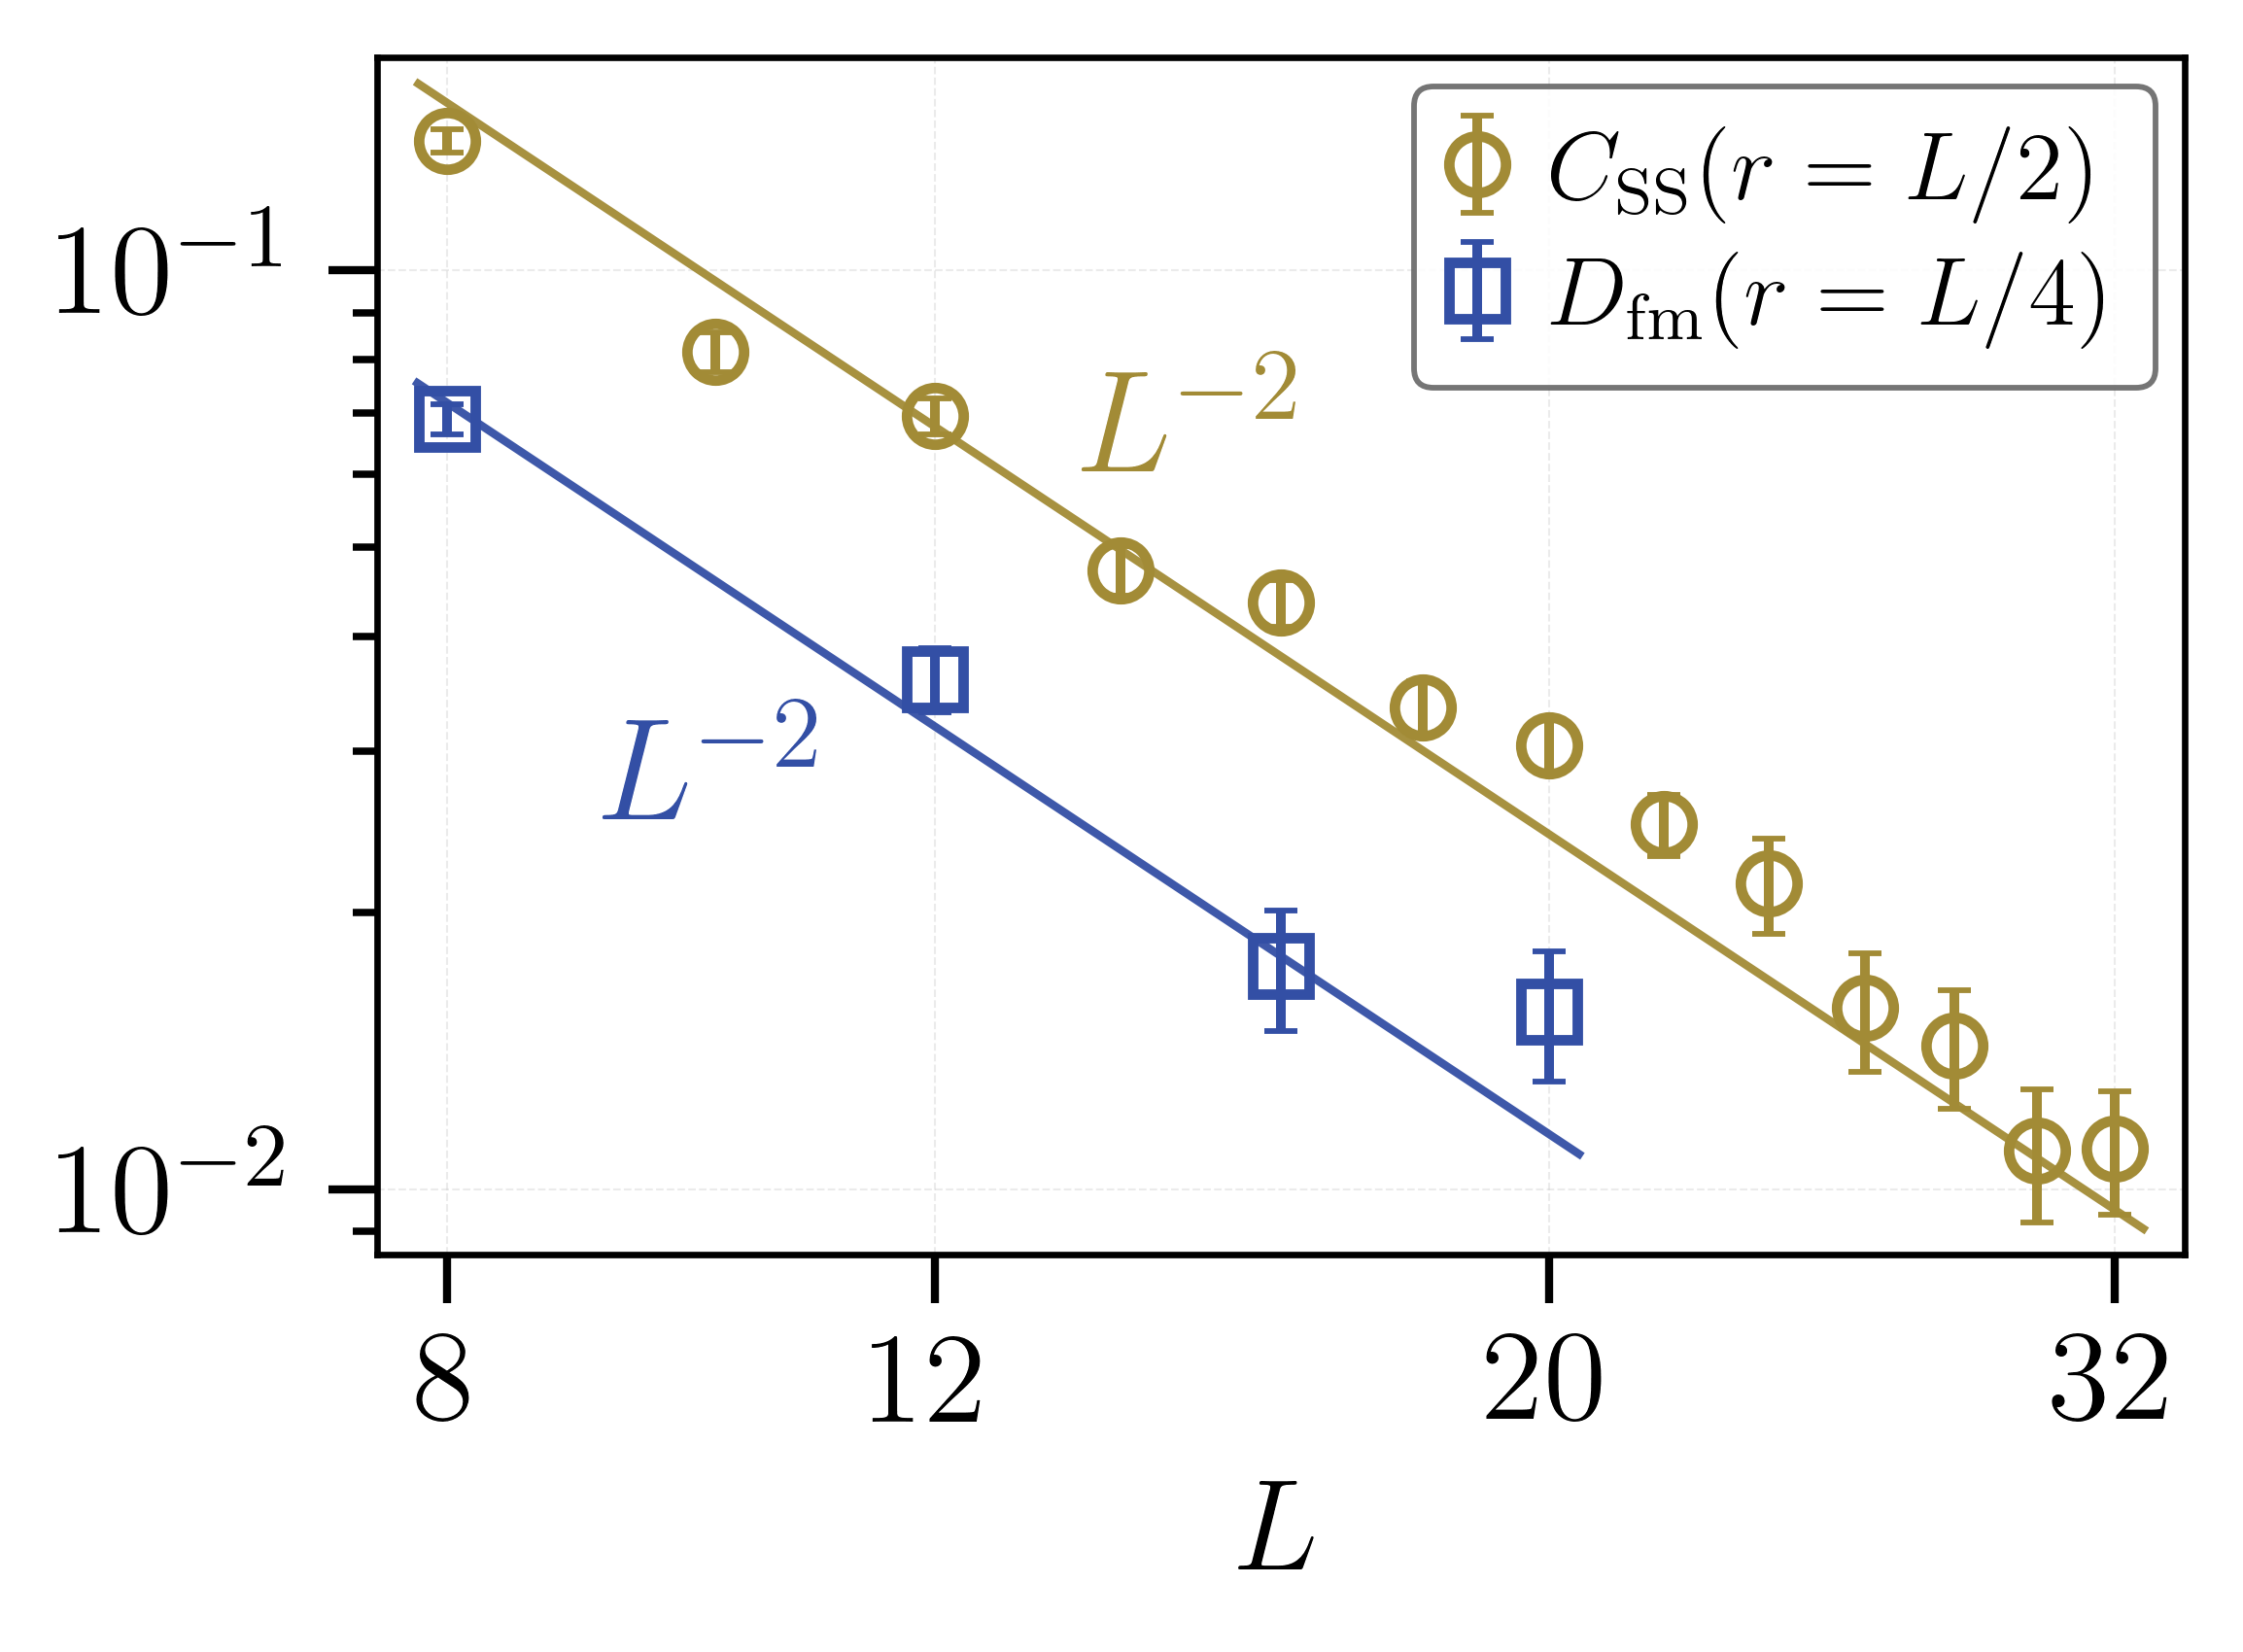

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, NullLocator
import matplotlib as mpl

# ---------------------------------------------------------
# Matplotlib / LaTeX settings 
# ---------------------------------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ANNOT_FSIZE  = 18

# ---------------------------------------------------------
# Colors 
# ---------------------------------------------------------
ce_color  = '#a28b36ff'   # C_EA
dfm_color = '#334fa5ff'   # D_fm

# ---------------------------------------------------------
# ---------------------------------------------------------
def fit_A_fixed_m_minus2(L, y, yerr=None):
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.any(y <= 0):
        raise ValueError("All y must be positive to fit in log-space.")
    logA_samples = np.log(y) + 2.0 * np.log(L)

    if yerr is None:
        logA = np.mean(logA_samples)
    else:
        yerr = np.asarray(yerr, dtype=float)
        snr = y / yerr
        w = snr**2
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
        logA = np.sum(w * logA_samples) / np.sum(w) if np.sum(w) > 0 else np.mean(logA_samples)

    return float(np.exp(logA))

def place_scaling_label_near_line(ax, A, Lmin, Lmax, frac, y_mult, color,
                                 text=r'$L^{-2}$', fontsize=ANNOT_FSIZE,
                                 ha='left', va='center'):
    L0 = float(np.exp(np.log(Lmin) + frac * (np.log(Lmax) - np.log(Lmin))))
    y0 = float(A * L0**(-2))
    ax.text(
        L0, y0 * y_mult,
        text,
        fontsize=fontsize,
        color=color,
        ha=ha, va=va,
        zorder=6
    )

def extend_logL_span_for_marker(ax, Lmin, Lmax, markersize_pts, where="both", extra=1.0):
    fig = ax.figure
    fig.canvas.draw()
    r_pix = 0.5 * markersize_pts * fig.dpi / 72.0

    def delta_log10L_at(L0):
        eps = 0.01
        L1 = L0 * (1.0 + eps)
        x0 = ax.transData.transform((L0, 1.0))[0]
        x1 = ax.transData.transform((L1, 1.0))[0]
        dx = abs(x1 - x0)
        if dx <= 1e-9:
            return 0.01
        dlog10 = abs(np.log10(L1) - np.log10(L0))
        pix_per_log10 = dx / dlog10
        return extra * (r_pix / pix_per_log10)

    logLmin, logLmax = np.log10(Lmin), np.log10(Lmax)
    if where in ("both", "left"):
        logLmin -= delta_log10L_at(Lmin)
    if where in ("both", "right"):
        logLmax += delta_log10L_at(Lmax)
    return 10**logLmin, 10**logLmax

# ============================================================
# ============================================================
def _collect_fixed_fraction_vs_L_single_obs(
    df,
    frac,                 # (num, den): r/L = num/den
    mean_col,
    se_col,
    snr_cut=10.0,
    r_min=3,
    parity=None           
):
    num, den = frac
    L_vals = np.sort(df["L"].unique())

    L_sel_list, y_list, se_list = [], [], []

    for L in L_vals:
        if L % den != 0:
            continue

        r = (num * L) // den
        if r * den != num * L:
            continue

        if parity == "odd" and (r % 2 == 0):
            r -= 1
        if parity == "even" and (r % 2 == 1):
            r -= 1

        if r < r_min:
            continue

        row = df[(df["L"] == L) & (df["r"] == r)]
        if row.empty:
            continue

        mean_val = row[mean_col].values[0]
        se_val   = row[se_col].values[0]

        y_val = ((-1)**r) * mean_val

        if not (np.isfinite(y_val) and np.isfinite(se_val) and y_val > 0 and se_val > 0):
            continue

        snr_val = float(y_val / se_val)
        if not (np.isfinite(snr_val) and snr_val >= snr_cut):
            continue

        L_sel_list.append(L)
        y_list.append(y_val)
        se_list.append(se_val)

    L_arr = np.array(L_sel_list, dtype=float)
    y_arr = np.array(y_list, dtype=float)
    e_arr = np.array(se_list, dtype=float)

    if len(L_arr) > 0:
        order = np.argsort(L_arr)
        L_arr, y_arr, e_arr = L_arr[order], y_arr[order], e_arr[order]

    return L_arr, y_arr, e_arr

def _pick_label_from_frac(frac):
    num, den = frac
    if num == 1:
        return rf"r=L/{den}"
    return rf"r=\frac{{{num}}}{{{den}}}L"

# ============================================================
# ============================================================
def plot_EA_FM_fixed_frac_reference_style(
    frac_EA=(1, 2),             # EA: r=L/2
    frac_FM=(1, 4),             # FM: r=L/4
    csv_file=None,
    snr_cut_EA=10.0,
    snr_cut_FM=10.0,
    r_min=3,
    title=None,
    L_ticks=None,
    pdf_name=None,
    debug=False,
    ann_EA=(0.34, 1.55,  r'$L^{-2}$'),
    ann_FM=(0.12, 0.42, r'$L^{-2}$'),
):
    if csv_file is None:
        raise ValueError("csv_file must be provided.")
    df = pd.read_csv(csv_file)

    # EA from ss_mean / ss_se
    L_EA, y_EA, e_EA = _collect_fixed_fraction_vs_L_single_obs(
        df, frac=frac_EA,
        mean_col="ss_mean", se_col="ss_se",
        snr_cut=snr_cut_EA, r_min=r_min,
        parity="odd",  
    )

    L_FM, y_FM, e_FM = _collect_fixed_fraction_vs_L_single_obs(
        df, frac=frac_FM,
        mean_col="dd_shift_mean", se_col="dd_shift_se",
        snr_cut=snr_cut_FM, r_min=r_min,
        parity=None,
    )

    if debug:
        print("Selected EA L:", L_EA)
        print("Selected FM L:", L_FM)

    if len(L_EA) == 0 and len(L_FM) == 0:
        raise ValueError("No points available to plot after cuts.")

    fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

    # ---- plot points ----
    msize = 7

    if len(L_EA) > 0:
        eb = ax.errorbar(
            L_EA, y_EA, yerr=e_EA,
            fmt='o', color=ce_color, ecolor=ce_color,
            markersize=msize, markerfacecolor='none',
            linewidth=1.0,
            capsize=2, elinewidth=1.2, capthick=0.7,
            label=rf'$C_{{\mathrm{{SS}}}}({ _pick_label_from_frac(frac_EA) })$',
            zorder=3
        )
        eb[0].set_markeredgewidth(1.3)

    if len(L_FM) > 0:
        eb = ax.errorbar(
            L_FM, y_FM, yerr=e_FM,
            fmt='s', color=dfm_color, ecolor=dfm_color,
            markersize=msize, markerfacecolor='none',
            linewidth=1.0,
            capsize=2, elinewidth=1.2, capthick=0.7,
            label=rf'$D_{{\mathrm{{fm}}}}({ _pick_label_from_frac(frac_FM) })$',
            zorder=3
        )
        eb[0].set_markeredgewidth(1.3)

    ax.set_xscale('log')
    ax.set_yscale('log')

    # --------
    A_cea = None
    if len(L_EA) > 0:
        A_cea = fit_A_fixed_m_minus2(L_EA, y_EA, yerr=e_EA)
        Lmin_ext, Lmax_ext = extend_logL_span_for_marker(ax, L_EA.min(), L_EA.max(), msize, where="both", extra=1.0)
        L_fit = np.logspace(np.log10(Lmin_ext), np.log10(Lmax_ext), 500)
        ax.plot(L_fit, A_cea * L_fit**(-2), color=ce_color, lw=1.0, alpha = 0.95,zorder=2)

    A_dfm = None
    if len(L_FM) > 0:
        A_dfm = fit_A_fixed_m_minus2(L_FM, y_FM, yerr=e_FM)
      
        Lmin_ext, Lmax_ext = extend_logL_span_for_marker(ax, L_FM.min(), L_FM.max(), msize, where="both", extra=1.0)
        L_fit = np.logspace(np.log10(Lmin_ext), np.log10(Lmax_ext), 500)
        ax.plot(L_fit, A_dfm * L_fit**(-2), color=dfm_color, lw=1.0, alpha=0.95, zorder=2)

    # ---- annotations (no bbox) ----
    if A_cea is not None:
        f, ym, txt = ann_EA
        place_scaling_label_near_line(ax, A_cea, L_EA.min(), L_EA.max(),
                                      frac=f, y_mult=ym, color=ce_color, text=txt)
    if A_dfm is not None:
        f, ym, txt = ann_FM
        place_scaling_label_near_line(ax, A_dfm, L_FM.min(), L_FM.max(),
                                      frac=f, y_mult=ym, color=dfm_color, text=txt)

    # ---- axes formatting ----
    ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
    if title is not None:
        ax.set_title(title, fontsize=LABEL_FSIZE + 1)

    if L_ticks is not None:
        ax.set_xticks(list(L_ticks))
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    else:
        ax.xaxis.set_minor_locator(NullLocator())

    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)

    # -----
    y_pool = []
    if len(y_EA) > 0: y_pool.append(y_EA)
    if len(y_FM) > 0: y_pool.append(y_FM)
    if A_cea is not None:
        y_pool.append(np.array([A_cea * (L_EA.min()**(-2)), A_cea * (L_EA.max()**(-2))]))
    if A_dfm is not None:
        y_pool.append(np.array([A_dfm * (L_FM.min()**(-2)), A_dfm * (L_FM.max()**(-2))]))

    all_y = np.concatenate(y_pool)
    y_min, y_max = float(np.min(all_y)), float(np.max(all_y))
    ax.set_ylim(y_min / 1.12, y_max * 1.12)

    x_pool = []
    if len(L_EA) > 0: x_pool.append(L_EA)
    if len(L_FM) > 0: x_pool.append(L_FM)
    all_x = np.concatenate(x_pool)
    ax.set_xlim(float(np.min(all_x)) / 1.06, float(np.max(all_x)) * 1.06)

    leg = ax.legend(
        fontsize=LEGEND_FONTSIZE,
        loc='upper right',
        handlelength=0.5,
        handletextpad=0.5,
        borderpad=0.4,
        labelspacing=0.3,
        borderaxespad=0.3,
        frameon=True,
    )
    frame = leg.get_frame()
    frame.set_edgecolor('0.4')   # medium gray
    frame.set_linewidth(0.7)
    frame.set_facecolor('white')
    frame.set_alpha(0.9)
    
    if pdf_name is not None:
        plt.savefig(
            pdf_name,
            format="pdf",
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.08,
            transparent=False
        )
        print(f"Saved high-quality PDF as: {pdf_name}")

    plt.show()
    return fig, ax

# ============================================================
# Example call
# ============================================================
csv_file = "combined_dmrg_stats.csv"
fig, ax = plot_EA_FM_fixed_frac_reference_style(
    frac_EA=(1, 2),
    frac_FM=(1, 4),
    csv_file=csv_file,
    snr_cut_EA=3,
    snr_cut_FM=3,
    r_min=2,
    L_ticks=(8,12,20,32),
    debug=True,
    ann_EA=(0.38, 1.25,  r'$L^{-2}$'),
    ann_FM=(0.14, 0.50, r'$L^{-2}$'),
    pdf_name="Figs/AFM-Heisenberg-DMRG.pdf",
)

# Fig.4(c) - Supplemental Material

Selected L: [ 8. 10. 12. 14. 16. 18. 20. 22.]
Selected y: [0.00743676 0.00222646 0.00166994 0.0007098  0.0005332  0.00029851
 0.00025636 0.00014848]
Selected e: [8.72375559e-04 2.47659135e-04 2.16246421e-04 1.12202052e-04
 7.41641293e-05 5.24331665e-05 4.59559780e-05 2.86569625e-05]
Saved high-quality PDF as: Figs/AFM-Heisenberg-DMRG-D-sc.pdf


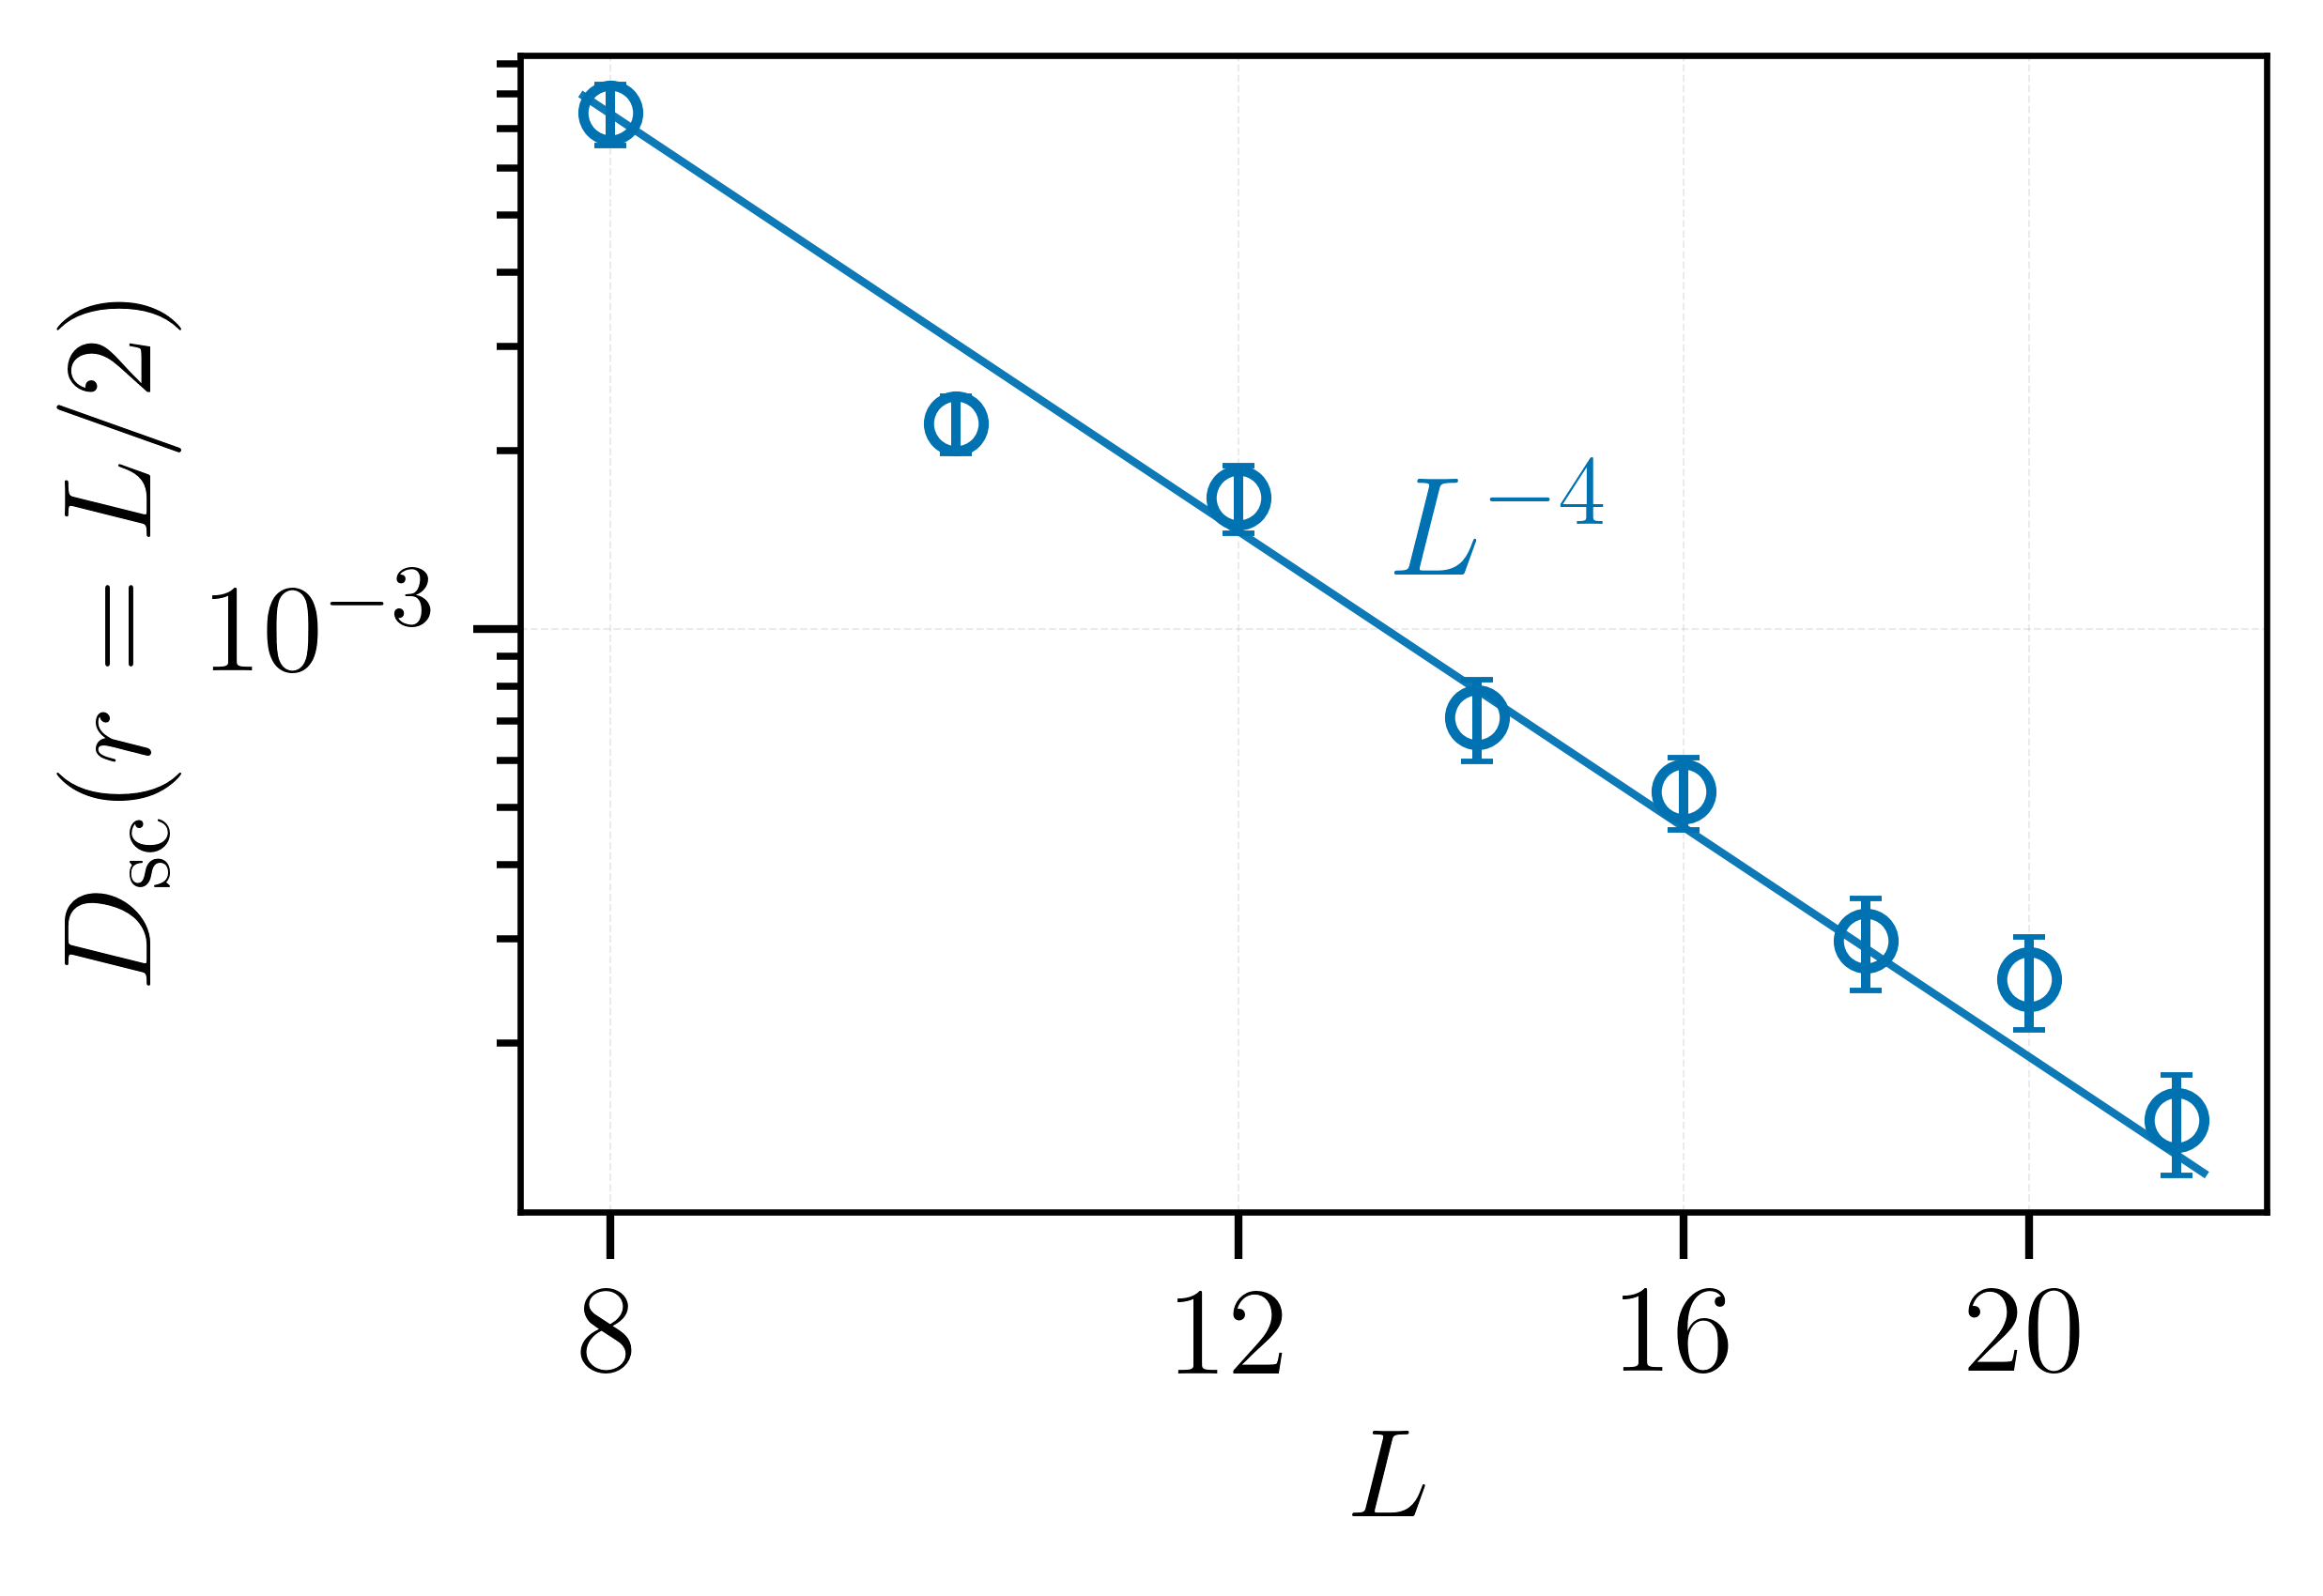

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, NullLocator
import matplotlib as mpl

# -----------------------------------
# Matplotlib / LaTeX settings 
# -----------------------------------
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LEGEND_FONTSIZE = 12
LABEL_FSIZE  = 16
TICK_FSIZE   = 16
ANNOT_FSIZE  = 18

# ---------------------------------------------------------
# Colors 
# ---------------------------------------------------------
orange_color = "#0072B2"   

# ============================================================
# ============================================================
def fit_A_fixed_m_minus4(L, y, yerr=None):
    L = np.asarray(L, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.any(y <= 0):
        raise ValueError("All y must be positive to fit in log-space.")
    logA_samples = np.log(y) + 4.0 * np.log(L)

    if yerr is None:
        logA = np.mean(logA_samples)
    else:
        yerr = np.asarray(yerr, dtype=float)
        snr = y / yerr
        w = snr**2
        w = np.where(np.isfinite(w) & (w > 0), w, 0.0)
        logA = np.sum(w * logA_samples) / np.sum(w) if np.sum(w) > 0 else np.mean(logA_samples)

    return float(np.exp(logA))

def place_scaling_label_near_line_m4(ax, A, Lmin, Lmax, frac, y_mult, color,
                                    text=r'$L^{-4}$', fontsize=ANNOT_FSIZE,
                                    ha='left', va='center'):
    L0 = float(np.exp(np.log(Lmin) + frac * (np.log(Lmax) - np.log(Lmin))))
    y0 = float(A * L0**(-4))
    ax.text(
        L0, y0 * y_mult,
        text,
        fontsize=fontsize,
        color=color,
        ha=ha, va=va,
        zorder=6
    )

def extend_logL_span_for_marker(ax, Lmin, Lmax, markersize_pts, where="both", extra=1.0):
    fig = ax.figure
    fig.canvas.draw()
    r_pix = 0.5 * markersize_pts * fig.dpi / 72.0

    def delta_log10L_at(L0):
        eps = 0.01
        L1 = L0 * (1.0 + eps)
        x0 = ax.transData.transform((L0, 1.0))[0]
        x1 = ax.transData.transform((L1, 1.0))[0]
        dx = abs(x1 - x0)
        if dx <= 1e-9:
            return 0.01
        dlog10 = abs(np.log10(L1) - np.log10(L0))
        pix_per_log10 = dx / dlog10
        return extra * (r_pix / pix_per_log10)

    logLmin, logLmax = np.log10(Lmin), np.log10(Lmax)
    if where in ("both", "left"):
        logLmin -= delta_log10L_at(Lmin)
    if where in ("both", "right"):
        logLmax += delta_log10L_at(Lmax)
    return 10**logLmin, 10**logLmax

# ============================================================
# ============================================================
def _collect_fixed_fraction_vs_L_single_obs(
    df,
    frac,                 # (num, den): r/L = num/den
    mean_col,
    se_col,
    snr_cut=3.0,
    r_min=2,
    parity=None,          
):
    num, den = frac
    L_vals = np.sort(df["L"].unique())

    L_sel_list, y_list, se_list = [], [], []

    for L in L_vals:
        if L % den != 0:
            continue

        r = (num * L) // den
        if r * den != num * L:
            continue

        if parity == "odd" and (r % 2 == 0):
            r -= 1
        if parity == "even" and (r % 2 == 1):
            r -= 1

        if r < r_min:
            continue

        row = df[(df["L"] == L) & (df["r"] == r)]
        if row.empty:
            continue

        mean_val = float(row[mean_col].values[0])
        se_val   = float(row[se_col].values[0])

        y_val = ((-1)**r) * mean_val

        if not (np.isfinite(y_val) and np.isfinite(se_val) and (y_val > 0.0) and (se_val > 0.0)):
            continue

        snr_val = y_val / se_val
        if not (np.isfinite(snr_val) and (snr_val >= snr_cut)):
            continue

        L_sel_list.append(L)
        y_list.append(y_val)
        se_list.append(se_val)

    L_arr = np.array(L_sel_list, dtype=float)
    y_arr = np.array(y_list, dtype=float)
    e_arr = np.array(se_list, dtype=float)

    if len(L_arr) > 0:
        order = np.argsort(L_arr)
        L_arr, y_arr, e_arr = L_arr[order], y_arr[order], e_arr[order]

    return L_arr, y_arr, e_arr

def _pick_label_from_frac(frac):
    num, den = frac
    if num == 1:
        return rf"r=L/{den}"
    return rf"r=\frac{{{num}}}{{{den}}}L"

# ============================================================
# Plot
# ============================================================
def plot_orange_ddc_fixed_frac_reference_style(
    csv_file,
    frac=(1, 4),
    snr_cut=3.0,
    r_min=2,
    parity=None,
    L_ticks=None,
    title=None,
    pdf_name=None,
    debug=False,
    ann=(0.18, 0.55, r'$L^{-4}$'),
    y_pad_lower=1.35,  
    y_pad_upper=1.18,   
):
    df = pd.read_csv(csv_file)

    L, y, e = _collect_fixed_fraction_vs_L_single_obs(
        df,
        frac=frac,
        mean_col="dd_c_mean",
        se_col="dd_c_se",
        snr_cut=snr_cut,
        r_min=r_min,
        parity=parity,
    )

    if debug:
        print("Selected L:", L)
        print("Selected y:", y)
        print("Selected e:", e)

    if len(L) == 0:
        raise ValueError("No points available to plot after cuts for dd_c_mean/dd_c_se.")

    fig, ax = plt.subplots(figsize=(4, 8/3), dpi=600)

    msize = 7
    eb = ax.errorbar(
        L, y, yerr=e,
        fmt='o', color=orange_color, ecolor=orange_color,
        markersize=msize, markerfacecolor='none',
        linewidth=1.0,
        capsize=2, elinewidth=1.2, capthick=0.7,
        zorder=3
    )
    eb[0].set_markeredgewidth(1.3)

    ax.set_xscale('log')
    ax.set_yscale('log')

    A = fit_A_fixed_m_minus4(L, y, yerr=e)
    Lmin_ext, Lmax_ext = extend_logL_span_for_marker(ax, L.min(), L.max(), msize, where="both", extra=1.0)
    L_fit = np.logspace(np.log10(Lmin_ext), np.log10(Lmax_ext), 500)
    ax.plot(L_fit, A * L_fit**(-4), color=orange_color, lw=1.0, alpha=0.95, zorder=2)

    f, ym, txt = ann
    place_scaling_label_near_line_m4(
        ax, A, L.min(), L.max(),
        frac=f, y_mult=ym, color=orange_color, text=txt
    )

    ax.set_xlabel(r'$L$', fontsize=LABEL_FSIZE)
    ax.set_ylabel(rf'$D_{{\mathrm{{sc}}}}({ _pick_label_from_frac(frac) })$', fontsize=LABEL_FSIZE)
    
    if title is not None:
        ax.set_title(title, fontsize=LABEL_FSIZE + 1)

    if L_ticks is not None:
        ax.set_xticks(list(L_ticks))
        ax.get_xaxis().set_major_formatter(FormatStrFormatter("%d"))
        ax.xaxis.set_minor_locator(NullLocator())
    else:
        ax.xaxis.set_minor_locator(NullLocator())

    ax.tick_params(axis='both', which='major', labelsize=TICK_FSIZE, length=6, width=1.0)
    ax.tick_params(axis='both', which='minor', labelsize=TICK_FSIZE, length=3, width=0.9)

    y_pool = np.concatenate([y, np.array([A * (L.min()**(-4)), A * (L.max()**(-4))])])
    y_min, y_max = float(np.min(y_pool)), float(np.max(y_pool))
    ax.set_ylim(y_min / y_pad_lower, y_max * y_pad_upper)

    ax.set_xlim(float(L.min()) / 1.06, float(L.max()) * 1.06)


    if pdf_name is not None:
        plt.savefig(
            pdf_name,
            format="pdf",
            dpi=600,
            bbox_inches="tight",
            pad_inches=0.08,
            transparent=False
        )
        print(f"Saved high-quality PDF as: {pdf_name}")

    plt.show()
    return fig, ax


csv_file = "combined_dmrg_stats.csv"
fig, ax = plot_orange_ddc_fixed_frac_reference_style(
    csv_file=csv_file,
    frac=(1, 2),
    snr_cut=5,
    r_min=2,
    parity=None,
    L_ticks=(8, 12, 16, 20, 32),
    debug=True,
    ann=(0.5, 1.45, r'$L^{-4}$'),
    y_pad_lower=1.25,  
    y_pad_upper=1.25,
    pdf_name="Figs/AFM-Heisenberg-DMRG-D-sc.pdf"
    
)